# Decision Tree Classifier for Bank Loan Approval

This notebook demonstrates a **lecture-quality introductory workflow** for a decision tree classifier using a small bank loan dataset.

## Learning objectives
- Understand how a decision tree learns classification rules.
- Prepare categorical and boolean features for scikit-learn.
- Split data into **training** and **test** sets.
- Compare **training accuracy** and **test accuracy**.
- Visualize the final tree and interpret its decision rules.

## Teaching note
This dataset is intentionally tiny. That makes it easy to inspect in class, but it also means model evaluation will be unstable. For a first lesson, we use a **train/test split** only. In larger projects, we would also discuss validation data or cross-validation.

## Import Libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

## Load and Inspect the Dataset

The target variable is `Outcome`, which records whether the bank **Approves** or **Rejects** a loan application.

In [9]:
df = pd.read_csv('bank_loan_appln.csv')
df

,ID,Age,Has_job,Own_house,Credit_rating,Outcome
0,1,young,False,False,fair,Reject
1,2,young,False,False,good,Reject
2,3,young,True,False,good,Approve
3,4,young,True,True,fair,Approve
4,5,young,False,False,fair,Reject
5,6,middle,False,False,fair,Reject
6,7,middle,False,False,good,Reject
7,8,middle,True,True,good,Approve
8,9,middle,False,True,excellent,Approve
9,10,middle,False,True,excellent,Approve


In [10]:
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())

print('\nClass distribution:')
print(df['Outcome'].value_counts())

Shape: (15, 6)

Missing values:
ID               0
Age              0
Has_job          0
Own_house        0
Credit_rating    0
Outcome          0
dtype: int64

Class distribution:
Outcome
Approve    9
Reject     6
Name: count, dtype: int64


## Preprocess the Data

We drop `ID` because it is only an identifier and should not help prediction.

For this simple classroom example:
- `Has_job` and `Own_house` are converted from boolean to integer.
- `Age` and `Credit_rating` are label-encoded.

## Teaching note
Label encoding is acceptable here because the dataset is tiny and the notebook is meant to illustrate the workflow. In a more advanced lesson, we would discuss when one-hot encoding is safer for nominal categories.

In [11]:
X = df.drop(columns=['ID', 'Outcome']).copy()
y = df['Outcome'].copy()

age_encoder = LabelEncoder()
credit_encoder = LabelEncoder()

X['Age'] = age_encoder.fit_transform(X['Age'])
X['Has_job'] = X['Has_job'].astype(int)
X['Own_house'] = X['Own_house'].astype(int)
X['Credit_rating'] = credit_encoder.fit_transform(X['Credit_rating'])

print('Encoded feature matrix:')
display(X)

print('Age mapping:', dict(zip(age_encoder.classes_, age_encoder.transform(age_encoder.classes_))))
print('Credit rating mapping:', dict(zip(credit_encoder.classes_, credit_encoder.transform(credit_encoder.classes_))))

Encoded feature matrix:


,Age,Has_job,Own_house,Credit_rating
0,2,0,0,1
1,2,0,0,2
2,2,1,0,2
3,2,1,1,1
4,2,0,0,1
5,0,0,0,1
6,0,0,0,2
7,0,1,1,2
8,0,0,1,0
9,0,0,1,0


Age mapping: {'middle': np.int64(0), 'old': np.int64(1), 'young': np.int64(2)}
Credit rating mapping: {'excellent': np.int64(0), 'fair': np.int64(1), 'good': np.int64(2)}


## Split into Training and Test Sets

This is the key correction to the earlier version of the notebook.

We train the model on one part of the data and evaluate it on a separate **held-out test set**. This gives a more honest estimate of performance on unseen examples.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

print('\nTraining features:')
display(X_train)

print('Test features:')
display(X_test)

Training set size: 10
Test set size: 5

Training features:


,Age,Has_job,Own_house,Credit_rating
12,1,1,0,2
0,2,0,0,1
5,0,0,0,1
2,2,1,0,2
3,2,1,1,1
13,1,1,0,0
7,0,1,1,2
10,1,0,1,0
6,0,0,0,2
1,2,0,0,2


Test features:


,Age,Has_job,Own_house,Credit_rating
4,2,0,0,1
11,1,0,1,2
9,0,0,1,0
14,1,0,0,1
8,0,0,1,0


## Train the Decision Tree Classifier

A decision tree recursively splits the data to reduce class impurity.

## Teaching note
- `criterion='gini'` means the tree uses **Gini impurity** to choose splits.
- `max_depth=3` limits tree growth and helps reduce overfitting.
- With very small datasets, trees can memorize the training set easily.

In [13]:
dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

dt_classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## Evaluate the Model

We calculate both training accuracy and test accuracy.

## Teaching note
- **Training accuracy** tells us how well the model fits the examples it already saw.
- **Test accuracy** is more important because it measures generalization.
- If training accuracy is much higher than test accuracy, the model may be **overfitting**.

In [14]:
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f'Training Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_test_pred

print('\nTest set predictions:')
display(results)

Training Accuracy: 1.00
Test Accuracy: 1.00

Test set predictions:


,Age,Has_job,Own_house,Credit_rating,Actual,Predicted
4,2,0,0,1,Reject,Reject
11,1,0,1,2,Approve,Approve
9,0,0,1,0,Approve,Approve
14,1,0,0,1,Reject,Reject
8,0,0,1,0,Approve,Approve


## Predict a New Applicant

We use a **one-row DataFrame with named columns** so the input format is explicit and consistent with training.

In [15]:
new_applicant = pd.DataFrame([
    {
        'Age': age_encoder.transform(['young'])[0],
        'Has_job': 1,
        'Own_house': 0,
        'Credit_rating': credit_encoder.transform(['fair'])[0]
    }
])

prediction = dt_classifier.predict(new_applicant)[0]

display(new_applicant)
print('Predicted outcome for the new applicant:', prediction)

,Age,Has_job,Own_house,Credit_rating
0,2,1,0,1


Predicted outcome for the new applicant: Approve


## Visualize the Decision Tree

The tree visualization helps students connect the learned model to human-readable decision rules.

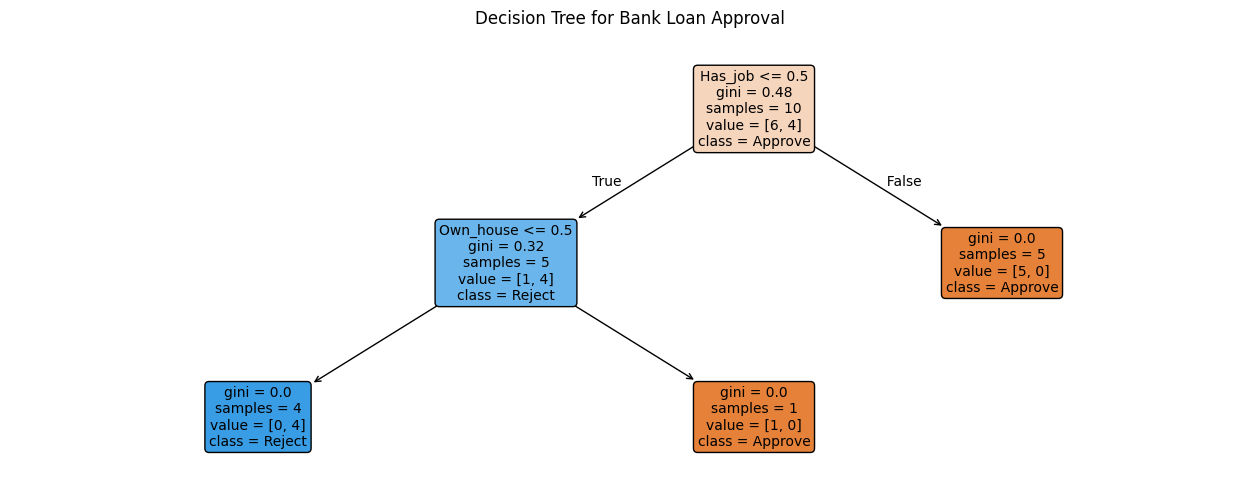

In [16]:
plt.figure(figsize=(16, 6))

plot_tree(
    dt_classifier,
    feature_names=X.columns,
    class_names=dt_classifier.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Decision Tree for Bank Loan Approval')
plt.show()

## Summary and Discussion

### What students should remember
- A decision tree learns a sequence of if-then rules.
- Model evaluation should be done on **held-out data**, not the same data used for training.
- High training accuracy alone is not enough.
- Small datasets are useful for explanation, but weak for reliable evaluation.

### Extension ideas for class
- Change `max_depth` and observe how the tree changes.
- Compare `criterion='gini'` with `criterion='entropy'`.
- Discuss when to use a validation set or cross-validation.